# Masked JEPA WFV Embedding Analysis

Analyze JEPA embeddings from the current walk-forward validation setup.

This notebook is compatible with:
- WFV window manifests under `logs/wfv/<run_name>`
- masked JEPA checkpoints (`best.pt`)
- the current context-only dataset format
- the current `PatchTSTEncoder` / masked `JEPA` implementation


In [1]:
from pathlib import Path
import sys
import json
import math
import random

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)


PROJECT_ROOT: C:\python\koulu\Gradu


In [2]:
from src.Datasets.multi_asset_dataset import Dataset_Finance_MultiAsset
from src.Training.callbacks import make_patches
from src.models.jepa.jepa import JEPA
from src.models.time_series.patchTransformer import PatchTSTEncoder


In [10]:
RUN_NAME = "wfv_run2"
WINDOW_TAG = "w000"          # e.g. "w003" or None for all windows
SPLIT = "train"         # train | val | test
SAMPLES_PER_WINDOW = 512   # max sampled sequences per window for embedding extraction
RANDOM_SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

RUN_LOG_DIR = PROJECT_ROOT / "logs" / "wfv" / RUN_NAME
RUN_CKPT_DIR = PROJECT_ROOT / "checkpoints" / RUN_NAME
MANIFEST_PATH = RUN_LOG_DIR / f"{RUN_NAME}_windows.json"
BASE_CONFIG_PATH = PROJECT_ROOT / "configs" / "jepa_wfv.json"

print(RUN_LOG_DIR)
print(RUN_CKPT_DIR)
print(MANIFEST_PATH)


C:\python\koulu\Gradu\logs\wfv\wfv_run2
C:\python\koulu\Gradu\checkpoints\wfv_run2
C:\python\koulu\Gradu\logs\wfv\wfv_run2\wfv_run2_windows.json


In [11]:
assert MANIFEST_PATH.exists(), f"Missing manifest: {MANIFEST_PATH}"
assert BASE_CONFIG_PATH.exists(), f"Missing JEPA config: {BASE_CONFIG_PATH}"

with MANIFEST_PATH.open("r", encoding="utf-8") as f:
    manifest = json.load(f)

manifest_run_name = manifest.get("run_name")
if manifest_run_name and manifest_run_name != RUN_NAME:
    print(f"Warning: manifest run_name={manifest_run_name} but notebook RUN_NAME={RUN_NAME}")

windows_df = pd.DataFrame(manifest["windows"]).sort_values("window_index").reset_index(drop=True)
if WINDOW_TAG is not None:
    windows_df = windows_df.loc[windows_df["window"] == WINDOW_TAG].reset_index(drop=True)

windows_df


,window,window_index,train_start,train_end,val_end,test_end,jepa_checkpoint,ppo_checkpoint
0,w000,0,2021-02-26T15:00:00+00:00,2024-02-25T23:59:59+00:00,2024-05-25T23:59:59+00:00,2024-08-25T23:59:59+00:00,checkpoints/wfv/wfv_run1/wfv_run1_jepa_w000/be...,checkpoints/wfv/wfv_run1/wfv_run1_ppo_w000/bes...


In [12]:
def resolve_project_path(value: str | Path | None) -> Path | None:
    if value is None:
        return None
    p = Path(value)
    return p if p.is_absolute() else (PROJECT_ROOT / p)


def build_dataset_kwargs(base_cfg: dict, window_row: pd.Series, split: str) -> dict:
    dataset_cfg = base_cfg["dataset"]
    kwargs = {
        "root_path": str(resolve_project_path(dataset_cfg["root_path"])),
        "data_path": dataset_cfg["data_path"],
        "start_date": dataset_cfg.get("start_date"),
        "split": split,
        "size": dataset_cfg["context_len"],
        "use_time_features": dataset_cfg.get("use_time_features", True),
        "rolling_window": dataset_cfg["rolling_window"],
        "train_split": dataset_cfg["train_split"],
        "test_split": dataset_cfg["test_split"],
        "tickers": dataset_cfg.get("tickers"),
        "regular_hours_only": dataset_cfg.get("regular_hours_only", True),
        "timeframe": dataset_cfg.get("timeframe", "15min"),
        "train_start_date": window_row["train_start"],
        "train_end_date": window_row["train_end"],
        "val_end_date": window_row["val_end"],
        "test_end_date": window_row["test_end"],
    }
    return kwargs


def load_base_config(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def resolve_checkpoint_path(window_row: pd.Series) -> Path:
    ckpt = resolve_project_path(window_row["jepa_checkpoint"])
    if ckpt.exists():
        return ckpt
    # Fallback for stale manifests that point to another run name.
    fallback = RUN_CKPT_DIR / f"{RUN_NAME}_jepa_{window_row['window']}" / "best.pt"
    if fallback.exists():
        return fallback
    raise FileNotFoundError(f"Missing JEPA checkpoint: {ckpt} (fallback tried: {fallback})")


def build_jepa_from_checkpoint(base_cfg: dict, checkpoint_path: Path, num_assets: int):
    model_cfg = base_cfg["jepa_model"]
    use_asset_embeddings = bool(model_cfg.get("use_asset_embeddings", False))
    encoder_num_assets = num_assets if use_asset_embeddings else None

    context_enc = PatchTSTEncoder(
        patch_len=model_cfg["patch_len"],
        d_model=model_cfg["d_model"],
        n_features=model_cfg["n_features"],
        n_time_features=model_cfg["n_time_features"],
        nhead=model_cfg["nhead"],
        num_layers=model_cfg["num_layers"],
        dim_ff=model_cfg["dim_ff"],
        dropout=model_cfg["dropout"],
        add_cls=model_cfg.get("add_cls", True),
        pooling=model_cfg["pooling"],
        num_assets=encoder_num_assets,
    )
    target_enc = PatchTSTEncoder(
        patch_len=model_cfg["patch_len"],
        d_model=model_cfg["d_model"],
        n_features=model_cfg["n_features"],
        n_time_features=model_cfg["n_time_features"],
        nhead=model_cfg["nhead"],
        num_layers=model_cfg["num_layers"],
        dim_ff=model_cfg["dim_ff"],
        dropout=model_cfg["dropout"],
        add_cls=model_cfg.get("add_cls", True),
        pooling=model_cfg["pooling"],
        num_assets=encoder_num_assets,
    )
    model = JEPA(
        context_enc=context_enc,
        target_enc=target_enc,
        d_model=model_cfg["d_model"],
        ema_tau_min=model_cfg["ema_tau_min"],
        ema_tau_max=model_cfg["ema_tau_max"],
        nhead=model_cfg["nhead"],
        dim_ff=model_cfg["dim_ff"],
        dropout=model_cfg["dropout"],
        predictor_num_layers=model_cfg.get("predictor_num_layers", 2),
        mask_ratio=model_cfg.get("mask_ratio", 0.5),
    )

    checkpoint = torch.load(checkpoint_path, map_location="cpu")
    missing, unexpected = model.load_state_dict(checkpoint["model"], strict=False)
    if missing:
        print("Missing keys:", missing)
    if unexpected:
        print("Unexpected keys:", unexpected)
    model.eval().to(DEVICE)
    return model, checkpoint


def sample_indices(n_total: int, n_sample: int) -> np.ndarray:
    n = min(n_total, n_sample)
    return np.random.choice(n_total, size=n, replace=False)


In [13]:
base_cfg = load_base_config(BASE_CONFIG_PATH)
windows_df[["window", "window_index", "train_start", "train_end", "val_end", "test_end"]]


,window,window_index,train_start,train_end,val_end,test_end
0,w000,0,2021-02-26T15:00:00+00:00,2024-02-25T23:59:59+00:00,2024-05-25T23:59:59+00:00,2024-08-25T23:59:59+00:00


In [15]:
def extract_window_embeddings(window_row: pd.Series, split: str = SPLIT, max_samples: int = SAMPLES_PER_WINDOW):
    dataset_kwargs = build_dataset_kwargs(base_cfg, window_row, split=split)
    print("Dataset root:", dataset_kwargs["root_path"], "| split:", split, "| window:", window_row["window"])
    dataset = Dataset_Finance_MultiAsset(**dataset_kwargs)
    ckpt_path = resolve_checkpoint_path(window_row)
    print("Checkpoint:", ckpt_path)
    model, checkpoint = build_jepa_from_checkpoint(base_cfg, ckpt_path, num_assets=dataset.num_asset_ids)

    idxs = sample_indices(len(dataset), max_samples)
    rows = []

    model_cfg = base_cfg["jepa_model"]
    patch_len = model_cfg["patch_len"]
    patch_stride = model_cfg["patch_stride"]

    with torch.no_grad():
        for ds_idx in idxs:
            sample = dataset[int(ds_idx)]
            x_context = sample["x_context"].unsqueeze(0).to(DEVICE)
            t_context = sample["t_context"].unsqueeze(0).to(DEVICE)
            asset_id = sample["asset_id"].unsqueeze(0).to(DEVICE)

            x_patch = make_patches(x_context, patch_len, patch_stride)
            t_patch = make_patches(t_context, patch_len, patch_stride)

            z_pooled = model.context_enc(x_patch, t_patch, asset_id=asset_id).squeeze(0).cpu().numpy()
            z_tokens = model.context_enc(x_patch, t_patch, asset_id=asset_id, return_tokens=True).squeeze(0).cpu().numpy()
            pred_masked, z_target = model.forward_masked(x_patch, t_patch, asset_id=asset_id)
            masked_loss = torch.nn.functional.smooth_l1_loss(pred_masked, z_target).item()
            cosine = torch.nn.functional.cosine_similarity(
                pred_masked.reshape(-1, pred_masked.shape[-1]),
                z_target.reshape(-1, z_target.shape[-1]),
                dim=-1,
            ).mean().item()

            asset_idx = int(sample["asset_id"].item())
            asset_name = dataset.asset_universe[asset_idx] if 0 <= asset_idx < len(dataset.asset_universe) else str(asset_idx)
            rows.append(
                {
                    "window": window_row["window"],
                    "window_index": int(window_row["window_index"]),
                    "dataset_index": int(ds_idx),
                    "asset_idx": asset_idx,
                    "asset_id": asset_name,
                    "masked_loss": masked_loss,
                    "masked_cosine": cosine,
                    "embedding_norm": float(np.linalg.norm(z_pooled)),
                    "token_std": float(z_tokens.std()),
                    "pooled_embedding": z_pooled,
                    "token_embeddings": z_tokens,
                }
            )

    frame = pd.DataFrame(rows)
    return dataset, model, checkpoint, frame


In [16]:
window_results = {}
summary_rows = []

for _, window_row in windows_df.iterrows():
    dataset, model, checkpoint, frame = extract_window_embeddings(window_row)
    window_results[window_row["window"]] = {
        "dataset": dataset,
        "model": model,
        "checkpoint": checkpoint,
        "frame": frame,
    }
    summary_rows.append(
        {
            "window": window_row["window"],
            "n_assets": len(dataset.asset_ids),
            "n_samples": len(frame),
            "masked_loss_mean": frame["masked_loss"].mean(),
            "masked_loss_std": frame["masked_loss"].std(),
            "masked_cosine_mean": frame["masked_cosine"].mean(),
            "embedding_norm_mean": frame["embedding_norm"].mean(),
            "token_std_mean": frame["token_std"].mean(),
            "checkpoint_epoch": int(checkpoint.get("epoch", -1)),
            "checkpoint_global_step": int(checkpoint.get("global_step", -1)),
        }
    )

summary_df = pd.DataFrame(summary_rows).sort_values("window").reset_index(drop=True)
summary_df


Dataset root: C:\python\koulu\Gradu\Data\polygon | split: train | window: w000
[Dataset_Finance_MultiAsset] Global date splits: mode=window train_start=2021-02-26 15:00:00+00:00 train_end=2024-02-25 23:59:59+00:00 val_end=2024-05-25 23:59:59+00:00 test_end=2024-08-25 23:59:59+00:00 n_dates=33179 n_train=20285 n_val=1728 n_test=1663
Checkpoint: C:\python\koulu\Gradu\checkpoints\wfv_run2\wfv_run2_jepa_w000\best.pt


c:\Users\ollik\miniconda3\envs\.graduenv\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
C:\Users\ollik\AppData\Local\Temp\ipykernel_100084\1601927134.py:91: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `

,window,n_assets,n_samples,masked_loss_mean,masked_loss_std,masked_cosine_mean,embedding_norm_mean,token_std_mean,checkpoint_epoch,checkpoint_global_step
0,w000,33,512,0.012728,0.003276,0.987228,13.960192,1.003419,47,60864


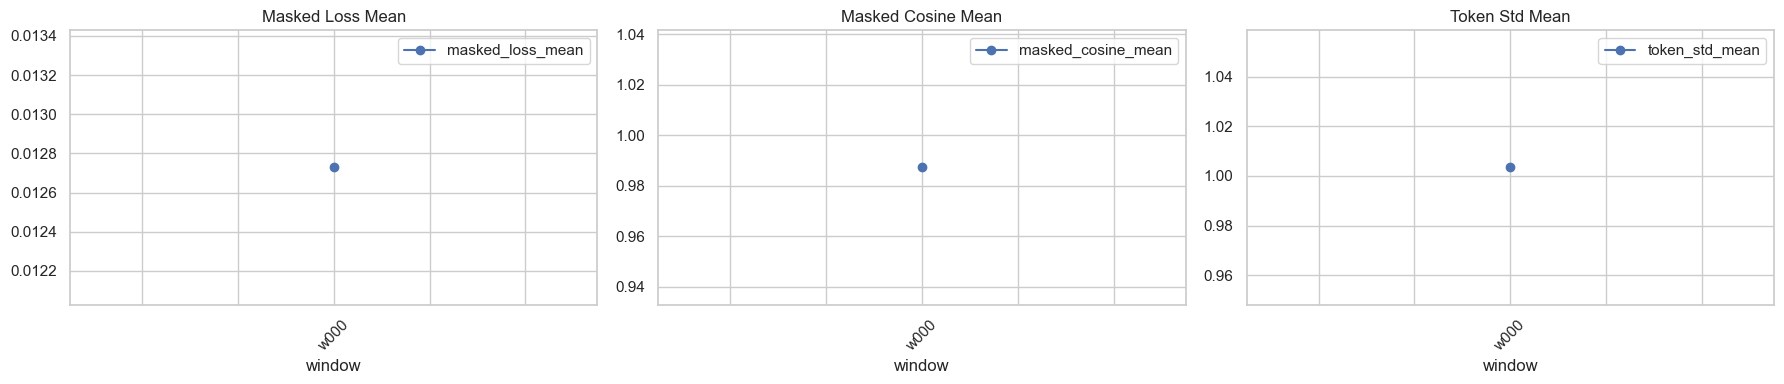

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
summary_df.plot(x="window", y="masked_loss_mean", marker="o", ax=axes[0], title="Masked Loss Mean")
summary_df.plot(x="window", y="masked_cosine_mean", marker="o", ax=axes[1], title="Masked Cosine Mean")
summary_df.plot(x="window", y="token_std_mean", marker="o", ax=axes[2], title="Token Std Mean")
for ax in axes:
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()


In [18]:
all_frames = pd.concat([v["frame"] for v in window_results.values()], ignore_index=True)
asset_summary = (
    all_frames.groupby(["window", "asset_id"], as_index=False)
    .agg(
        masked_loss_mean=("masked_loss", "mean"),
        masked_cosine_mean=("masked_cosine", "mean"),
        embedding_norm_mean=("embedding_norm", "mean"),
        token_std_mean=("token_std", "mean"),
        n=("dataset_index", "count"),
    )
)
asset_summary.head()


,window,asset_id,masked_loss_mean,masked_cosine_mean,embedding_norm_mean,token_std_mean,n
0,w000,AAPL,0.011514,0.988462,13.967551,1.003820,18
1,w000,AMGN,0.010895,0.989078,13.952284,1.003197,14
2,w000,AMZN,0.013562,0.986401,13.960889,1.003690,16
3,w000,AXP,0.014146,0.985790,13.965303,1.002946,23
4,w000,BA,0.012663,0.987305,13.969514,1.003590,22


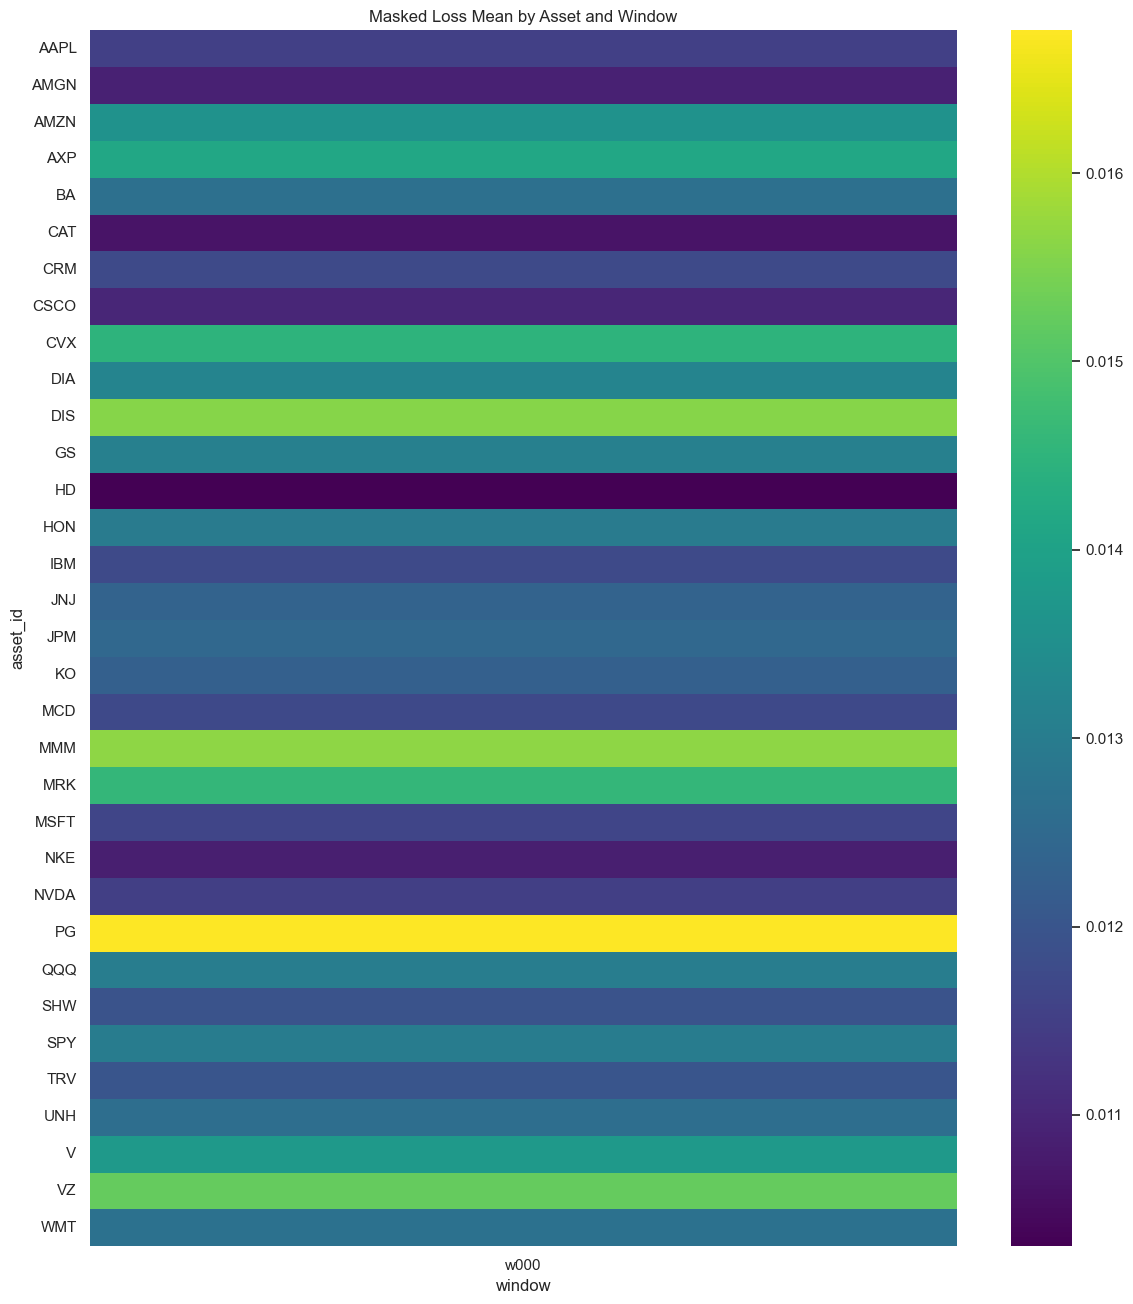

In [19]:
pivot = asset_summary.pivot(index="asset_id", columns="window", values="masked_loss_mean")
plt.figure(figsize=(12, max(4, 0.4 * len(pivot))))
sns.heatmap(pivot, cmap="viridis", annot=False)
plt.title("Masked Loss Mean by Asset and Window")
plt.tight_layout()


Explained variance ratio: [0.34522793 0.2895182 ]


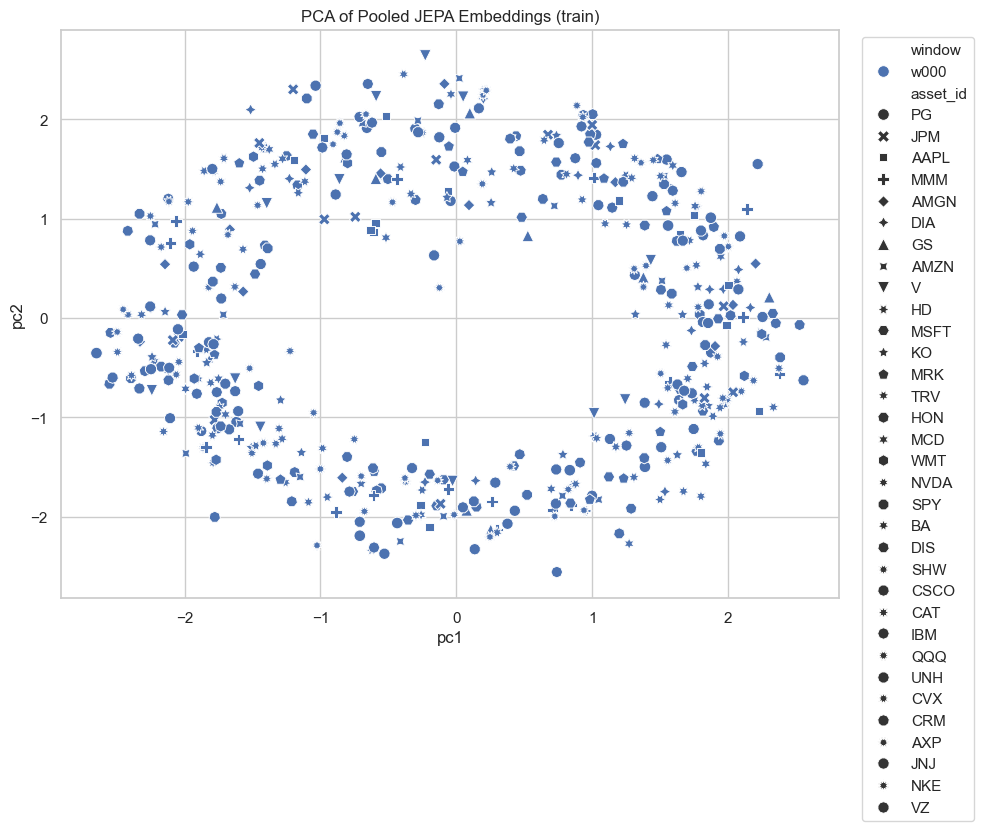

In [20]:
try:
    from sklearn.decomposition import PCA

    emb = np.stack(all_frames["pooled_embedding"].to_list())
    pca = PCA(n_components=2, random_state=RANDOM_SEED)
    xy = pca.fit_transform(emb)
    pca_df = all_frames[["window", "asset_id"]].copy()
    pca_df["pc1"] = xy[:, 0]
    pca_df["pc2"] = xy[:, 1]

    plt.figure(figsize=(10, 8))
    sns.scatterplot(data=pca_df, x="pc1", y="pc2", hue="window", style="asset_id", s=70)
    plt.title(f"PCA of Pooled JEPA Embeddings ({SPLIT})")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    print("Explained variance ratio:", pca.explained_variance_ratio_)
except Exception as exc:
    print("PCA unavailable:", exc)


In [21]:
selected_window = summary_df.iloc[-1]["window"]
selected = window_results[selected_window]["frame"].copy().sort_values("masked_loss", ascending=False)
selected[["asset_id", "masked_loss", "masked_cosine", "embedding_norm", "token_std"]].head(15)


,asset_id,masked_loss,masked_cosine,embedding_norm,token_std
438,V,0.044255,0.954268,13.998693,1.004126
124,VZ,0.032262,0.967305,13.974401,1.002500
298,UNH,0.028998,0.970354,13.997314,1.003648
65,AMZN,0.027276,0.972519,13.972435,1.003937
345,PG,0.025186,0.974468,13.973275,1.002035
405,MMM,0.022831,0.976988,13.948518,1.002852
401,MRK,0.021923,0.977809,13.991610,1.002758
28,DIS,0.021585,0.978175,13.921929,1.003149
59,JNJ,0.021322,0.978571,13.987567,1.003447
505,GS,0.021314,0.978568,13.960982,1.005464


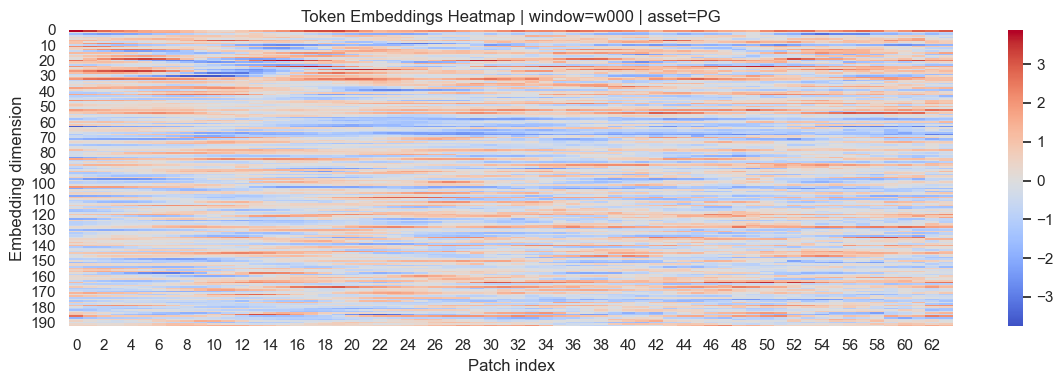

In [22]:
selected_window = summary_df.iloc[-1]["window"]
selected_frame = window_results[selected_window]["frame"]
example = selected_frame.iloc[0]

tokens = example["token_embeddings"]
plt.figure(figsize=(12, 4))
sns.heatmap(tokens.T, cmap="coolwarm", center=0)
plt.title(f"Token Embeddings Heatmap | window={selected_window} | asset={example['asset_id']}")
plt.xlabel("Patch index")
plt.ylabel("Embedding dimension")
plt.tight_layout()


In [23]:
summary_path = RUN_LOG_DIR / f"{RUN_NAME}_jepa_embedding_summary_{SPLIT}.csv"
asset_summary_path = RUN_LOG_DIR / f"{RUN_NAME}_jepa_embedding_asset_summary_{SPLIT}.csv"
summary_df.to_csv(summary_path, index=False)
asset_summary.to_csv(asset_summary_path, index=False)
print(summary_path)
print(asset_summary_path)


C:\python\koulu\Gradu\logs\wfv\wfv_run2\wfv_run2_jepa_embedding_summary_train.csv
C:\python\koulu\Gradu\logs\wfv\wfv_run2\wfv_run2_jepa_embedding_asset_summary_train.csv
